# Como evoluiu a felicidade nos países mais e menos felizes entre 2005 e 2023?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df= pd.read_excel('happiness_report_2024.xls')

In [3]:
df2= df[['year', 'Country name', 'Life Ladder']]
df2

,year,Country name,Life Ladder
0,2008,Afghanistan,3.723590
1,2009,Afghanistan,4.401778
2,2010,Afghanistan,4.758381
3,2011,Afghanistan,3.831719
4,2012,Afghanistan,3.782938
...,...,...,...
2358,2019,Zimbabwe,2.693523
2359,2020,Zimbabwe,3.159802
2360,2021,Zimbabwe,3.154578
2361,2022,Zimbabwe,3.296220


In [4]:
    #ordeno pelos anos (ascendente) e pelos valores da ladder por (descendente)

df2 = df2.sort_values(['year', 'Life Ladder'], ascending=[True, False])
df2

,year,Country name,Life Ladder
539,2005,Denmark,8.018934
1482,2005,Netherlands,7.463979
349,2005,Canada,7.418048
1987,2005,Sweden,7.376316
81,2005,Australia,7.340688
...,...,...,...
1835,2023,Sierra Leone,3.466578
472,2023,Congo (Kinshasa),3.383398
258,2023,Botswana,3.331648
1277,2023,Malawi,3.272092


## Encontrar os 10 primeiros paises de cada ano

In [5]:
top_10=df2.groupby('year').head(10)
#agrupo pra me dar os 10 primeiros de cada ano, se nao agrupasse só apareciam os 10 primeiros de 2005
top_10

,year,Country name,Life Ladder
539,2005,Denmark,8.018934
1482,2005,Netherlands,7.463979
349,2005,Canada,7.418048
1987,2005,Sweden,7.376316
81,2005,Australia,7.340688
...,...,...,...
1594,2023,Norway,7.248675
2004,2023,Sweden,7.160777
1129,2023,Kuwait,7.130284
97,2023,Australia,7.024582


## Encontrar os 10 últimos paises em cada ano

In [6]:
ultimos_10=df2.groupby('year').tail(10)
ultimos_10

,year,Country name,Life Ladder
1046,2005,Jordan,6.294660
771,2005,Greece,6.006310
1684,2005,Poland,5.587209
1177,2005,Lebanon,5.491245
923,2005,Iran,5.308190
...,...,...,...
1835,2023,Sierra Leone,3.466578
472,2023,Congo (Kinshasa),3.383398
258,2023,Botswana,3.331648
1277,2023,Malawi,3.272092


Visto que seria muito confuso ter 20 paises a aparecer no grafico em cada ano, pra simplificar vou fazer a media do top 10 e a media dos ultimos 10


In [7]:
# calcular a média por ano do top10

top10_mean = top_10.groupby('year')['Life Ladder'].mean()
top10_mean
#o index desta serie é o ano e os values a life ladder

year
2005    7.337570
2006    7.230475
2007    7.432915
2008    7.543048
2009    7.335608
2010    7.472358
2011    7.430079
2012    7.515215
2013    7.459507
2014    7.369695
2015    7.438931
2016    7.441275
2017    7.473629
2018    7.453999
2019    7.495621
2020    7.437950
2021    7.432625
2022    7.384357
2023    7.298398
Name: Life Ladder, dtype: float64

In [8]:
ultimos10_mean = ultimos_10.groupby('year')['Life Ladder'].mean()
ultimos10_mean
#o index desta serie é o ano e os values a life ladder

year
2005    5.404134
2006    3.586525
2007    3.857462
2008    3.546116
2009    3.827205
2010    3.735815
2011    3.677025
2012    3.596098
2013    3.458015
2014    3.322515
2015    3.425297
2016    3.276524
2017    3.301860
2018    3.437865
2019    3.283186
2020    3.983367
2021    3.337487
2022    2.958408
2023    3.278200
Name: Life Ladder, dtype: float64

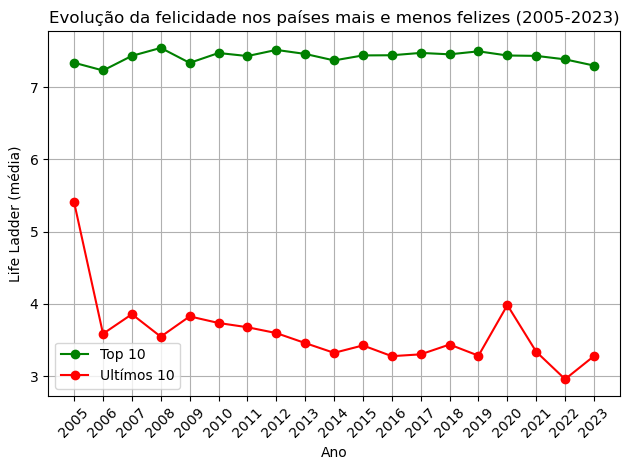

In [9]:
# Grafico de linhas com anos no eixo X, life ladder no Y
fig, ax = plt.subplots()
#formar 2 linhas no grafico correspondentes às medias obtidas em cada ano - uma pa
ax.plot(top10_mean.index, top10_mean.values, label='Top 10', color='green', marker='o')
ax.plot(ultimos10_mean.index, ultimos10_mean.values, label='Ultímos 10', color='red', marker='o')

ax.set_title('Evolução da felicidade nos países mais e menos felizes (2005-2023)')
ax.set_xlabel('Ano')
ax.set_ylabel('Life Ladder (média)')
ax.set_xticks(top10_mean.index)
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Interpretação do grafico 1

### porque é que em 2005, a media dos paises menos felizes deu muito mais elevada do que nos anos seguintes?

In [10]:
df2[df2['year']==2005].info()

<class 'pandas.core.frame.DataFrame'>
Index: 27 entries, 539 to 2137
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          27 non-null     int64  
 1   Country name  27 non-null     object 
 2   Life Ladder   27 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 864.0+ bytes


In [11]:
ultimos_10[ultimos_10['year']==2005]

,year,Country name,Life Ladder
1046,2005,Jordan,6.294660
771,2005,Greece,6.006310
1684,2005,Poland,5.587209
1177,2005,Lebanon,5.491245
923,2005,Iran,5.308190
1596,2005,Pakistan,5.224658
859,2005,Hungary,5.193933
597,2005,Egypt,5.167754
1722,2005,Romania,5.048648
2137,2005,Türkiye,4.718734


Apenas tem 27 paises com informação recolhida. Alem disso, muitos dos paises que tem life ladder muito baixas nos anos seguintes não estão aqui(afeganistão, zimbabue, tanzania

 ### Porque é que em 2020 aumentou?

In [33]:
df2[df2['year']==2020]

,year,Country name,Life Ladder
677,2020,Finland,7.889350
883,2020,Iceland,7.575490
553,2020,Denmark,7.514631
2014,2020,Switzerland,7.508435
1495,2020,Netherlands,7.504448
...,...,...,...
901,2020,India,4.223866
1060,2020,Jordan,4.093992
2073,2020,Tanzania,3.785684
2359,2020,Zimbabwe,3.159802


In [34]:
df2.groupby('year')['Country name'].count()
# número de países em cada ano

year
2005     27
2006     89
2007    102
2008    110
2009    114
2010    124
2011    146
2012    141
2013    136
2014    144
2015    142
2016    141
2017    147
2018    141
2019    143
2020    116
2021    122
2022    140
2023    138
Name: Country name, dtype: int64

Não estava o afeganistão  e houve menos paises em 2020

## Quais os maximos e minimos do top 10

In [13]:
print(round(top10_mean.values.min(),2))
print(round(top10_mean.values.max(),2))

7.23
7.54


## Quais os maximos e minimos dos ultimos 10

In [14]:
print(round(ultimos10_mean.values.min(),2))
print(round(ultimos10_mean.values.max(),2))

2.96
5.4


## Quais os paises mais felizes

In [15]:
top10_counts=top_10['Country name'].value_counts()
#gera uma serie
top10_counts=top10_counts.head(15)
#limitei a 15 pra nao ficar um grafico com demasiadas barras
top10_counts

Country name
Denmark          18
Netherlands      17
Finland          16
Sweden           16
Norway           13
Canada           12
Switzerland      11
Iceland          10
Israel           10
New Zealand      10
Australia        10
Austria           8
Costa Rica        7
Luxembourg        4
United States     4
Name: count, dtype: int64

## Quais os paises menos felizes

In [16]:
ultimos10_counts=ultimos_10['Country name'].value_counts()
#gera uma serie
ultimos10_counts=ultimos10_counts.head(15)
#limitei a 15 pra nao ficar um grafico com demasiadas barras
ultimos10_counts

Country name
Afghanistan     11
Zimbabwe        10
Tanzania        10
Rwanda           9
Benin            8
Botswana         8
Sierra Leone     7
Malawi           7
Burkina Faso     6
Haiti            6
Chad             6
Yemen            5
Burundi          5
Lebanon          5
Cambodia         5
Name: count, dtype: int64

### Visualização paises mais e menos felizes

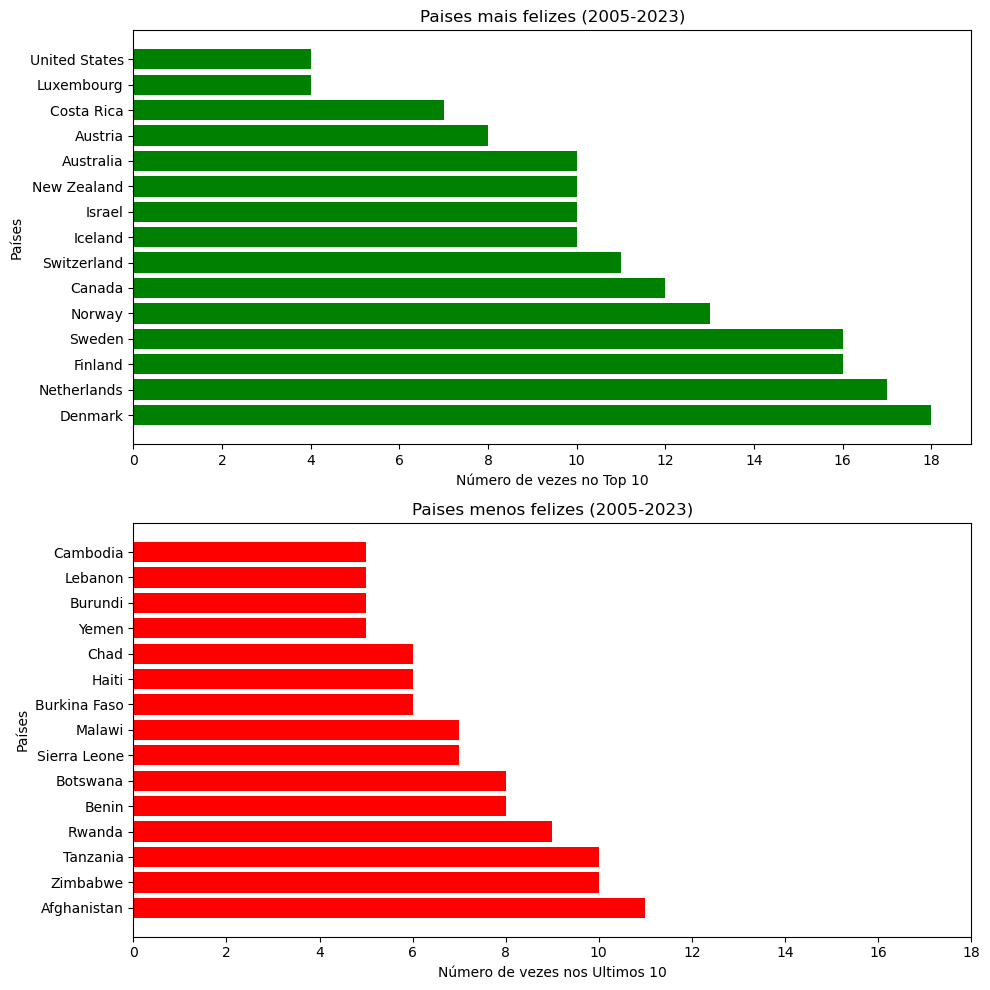

In [21]:
fig, ax = plt.subplots(2,figsize=(10, 10))
ax[0].barh(top10_counts.index, top10_counts.values, color='green')
ax[0].set_xlabel('Número de vezes no Top 10')
ax[0].set_ylabel('Países')
ax[0].set_title('Paises mais felizes (2005-2023)')
ax[0].set_xticks(range(0, 20, 2))

ax[1].barh(ultimos10_counts.index, ultimos10_counts.values, color='red')
ax[1].set_xlabel('Número de vezes nos Ultimos 10')
ax[1].set_ylabel('Países')
ax[1].set_title('Paises menos felizes (2005-2023)')
ax[1].set_xticks(range(0, 20, 2))

fig.tight_layout()

plt.show()
